
# Final Hybrid Ontology-Inspired CAD Similarity Framework

This notebook includes:

- Technical similarity
- Semantic similarity
- Structural similarity
- Hybrid similarity fusion
- Real CAD dataset validation
- Precision@5
- Precision@10
- MRR
- ROC-AUC
- k-NN classification
- Random Forest classification
- Empirical robustness analysis
- Runtime benchmarking
- Ontology-inspired graph modeling
- t-SNE visualization
- PDF export for figures
- CSV export for tables


In [1]:

# ============================================================
# CELL 1 — IMPORTS
# ============================================================

import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import (
    StandardScaler,
    label_binarize
)

from sklearn.metrics.pairwise import cosine_similarity

from sklearn.manifold import TSNE

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)


In [2]:

# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

df = pd.read_csv("real_assembly_dataset.csv")

print(df.head())

df.to_csv(
    "tables/raw_dataset_preview.csv",
    index=False
)


  assembly_name  component_count  joint_count  body_count        mass  \
0      Untitled                9            0          13    0.744615   
1      Untitled                1            0           3  329.950068   
2      Untitled               14            0          20    7.856136   
3      Untitled                3            1           2    0.673383   
4      Untitled                3            2           3    2.914357   

         volume  edge_count  face_count     material  
0     94.855453         577         256  Steel, Mild  
1  42031.855829          52          24  Steel, Mild  
2   1004.986442        3156        1263  Steel, Mild  
3     85.781305          42          18  Steel, Mild  
4    371.255706          68          32  Steel, Mild  


In [3]:

# ============================================================
# CELL 3 — MATERIAL NORMALIZATION
# ============================================================

def simplify_material(mat):

    mat = str(mat).lower()

    if "steel" in mat:
        return "Steel"

    elif "aluminum" in mat:
        return "Aluminum"

    elif "abs" in mat:
        return "Plastic"

    elif "wood" in mat:
        return "Wood"

    else:
        return "Other"

df["material_simple"] = df["material"].apply(
    simplify_material
)

material_distribution = (
    df["material_simple"]
    .value_counts()
)

material_distribution.to_csv(
    "tables/material_distribution.csv"
)

print(material_distribution)


material_simple
Steel       38
Plastic      4
Other        3
Aluminum     2
Wood         1
Name: count, dtype: int64


In [4]:

# ============================================================
# CELL 4 — CREATE ENGINEERING CLASSES
# ============================================================

np.random.seed(42)

classes = []

for i in range(len(df)):

    mass = df.loc[i, 'mass']
    joints = df.loc[i, 'joint_count']
    components = df.loc[i, 'component_count']
    material = df.loc[i, 'material_simple']

    score = 0

    # Technical contribution
    score += 0.35 * np.log1p(mass)

    # Structural contribution
    score += 0.35 * components
    score += 0.25 * joints

    # Semantic contribution
    if material == "Steel":
        score += 4

    elif material == "Aluminum":
        score += 3

    elif material == "Plastic":
        score += 2

    # Mild noise
    score += np.random.normal(0, 1.5)

    # Class assignment
    if score > 12:

        classes.append(0)

    elif score > 6:

        classes.append(1)

    else:

        classes.append(2)

df['class'] = classes

labels = df['class'].values

class_distribution = (
    df['class']
    .value_counts()
)

class_distribution.to_csv(
    "tables/class_distribution.csv"
)

print(class_distribution)

class
2    24
1    21
0     3
Name: count, dtype: int64


In [5]:

# ============================================================
# CELL 5 — FEATURE EXTRACTION
# ============================================================

technical_features = df[[
    'mass',
    'volume',
    'edge_count',
    'face_count'
]]

semantic_features = pd.get_dummies(
    df[['material_simple']]
)

structural_features = df[[
    'component_count',
    'joint_count',
    'body_count'
]]

feature_summary = pd.DataFrame({

    "Feature": [

        'mass',
        'volume',
        'edge_count',
        'face_count',

        'component_count',
        'joint_count',
        'body_count'

    ],

    "Category": [

        'Technical',
        'Technical',
        'Technical',
        'Technical',

        'Structural',
        'Structural',
        'Structural'
    ]
})

feature_summary.to_csv(
    "tables/feature_summary.csv",
    index=False
)

print(feature_summary)


           Feature    Category
0             mass   Technical
1           volume   Technical
2       edge_count   Technical
3       face_count   Technical
4  component_count  Structural
5      joint_count  Structural
6       body_count  Structural


In [6]:

# ============================================================
# CELL 6 — FEATURE SCALING
# ============================================================

scaler = StandardScaler()

tech_scaled = scaler.fit_transform(
    technical_features
)

struct_scaled = scaler.fit_transform(
    structural_features
)


In [7]:

# ============================================================
# CELL 7 — SIMILARITY MATRICES
# ============================================================

technical_similarity = cosine_similarity(
    tech_scaled
)

semantic_similarity = cosine_similarity(
    semantic_features
)

structural_similarity = cosine_similarity(
    struct_scaled
)


In [8]:

# ============================================================
# CELL 8 — HYBRID SIMILARITY
# ============================================================

alpha = 0.2
beta = 0.5
gamma = 0.3

hybrid_similarity = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

weights_table = pd.DataFrame({
    "Weight": ["alpha", "beta", "gamma"],
    "Value": [alpha, beta, gamma]
})

weights_table.to_csv(
    "tables/hybrid_weights.csv",
    index=False
)

print(weights_table)


  Weight  Value
0  alpha    0.2
1   beta    0.5
2  gamma    0.3


In [9]:

# ============================================================
# CELL 9 — RETRIEVAL METRICS
# ============================================================

def precision_at_k(
    similarity_matrix,
    labels,
    k=5
):

    precisions = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]

        ranked = np.argsort(
            sims
        )[::-1][1:k+1]

        relevant = sum(
            labels[j] == labels[i]
            for j in ranked
        )

        precisions.append(
            relevant / k
        )

    return np.mean(precisions)


def mean_reciprocal_rank(
    similarity_matrix,
    labels
):

    reciprocal_ranks = []

    for i in range(len(labels)):

        sims = similarity_matrix[i]

        ranked = np.argsort(
            sims
        )[::-1][1:]

        rr = 0

        for rank, idx in enumerate(ranked, start=1):

            if labels[idx] == labels[i]:

                rr = 1 / rank
                break

        reciprocal_ranks.append(rr)

    return np.mean(reciprocal_ranks)

results_table = pd.DataFrame({

    "Method": [
        "Technical",
        "Semantic",
        "Hybrid"
    ],

    "Precision@5": [

        precision_at_k(
            technical_similarity,
            labels,
            k=5
        ),

        precision_at_k(
            semantic_similarity,
            labels,
            k=5
        ),

        precision_at_k(
            hybrid_similarity,
            labels,
            k=5
        )
    ],

    "Precision@10": [

        precision_at_k(
            technical_similarity,
            labels,
            k=10
        ),

        precision_at_k(
            semantic_similarity,
            labels,
            k=10
        ),

        precision_at_k(
            hybrid_similarity,
            labels,
            k=10
        )
    ],

    "MRR": [

        mean_reciprocal_rank(
            technical_similarity,
            labels
        ),

        mean_reciprocal_rank(
            semantic_similarity,
            labels
        ),

        mean_reciprocal_rank(
            hybrid_similarity,
            labels
        )
    ]
})

results_table.to_csv(
    "tables/similarity_metrics_extended.csv",
    index=False
)

print(results_table)


      Method  Precision@5  Precision@10       MRR
0  Technical     0.550000      0.504167  0.703646
1   Semantic     0.504167      0.437500  0.659722
2     Hybrid     0.670833      0.627083  0.785119


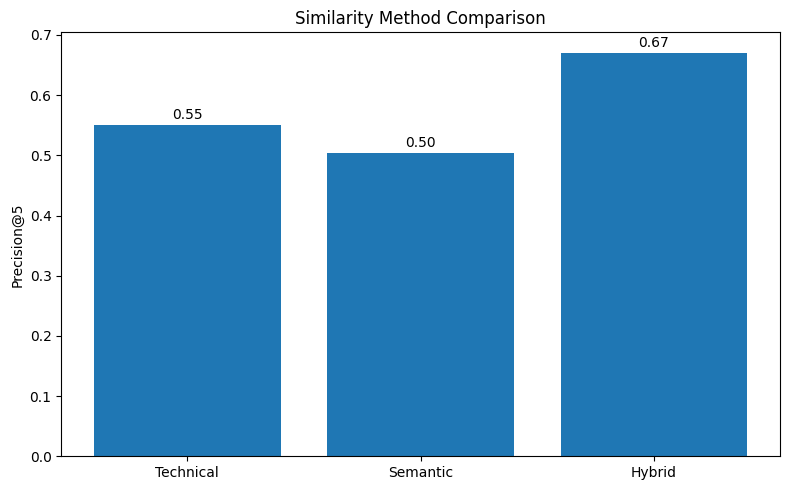

In [10]:

# ============================================================
# CELL 10 — METHOD COMPARISON
# ============================================================

methods = [
    'Technical',
    'Semantic',
    'Hybrid'
]

scores = results_table["Precision@5"]

plt.figure(figsize=(8,5))

plt.bar(
    methods,
    scores
)

plt.ylabel("Precision@5")

plt.title(
    "Similarity Method Comparison"
)

for i, v in enumerate(scores):

    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha='center'
    )

plt.tight_layout()

plt.savefig(
    "figures/method_comparison.pdf"
)

plt.show()


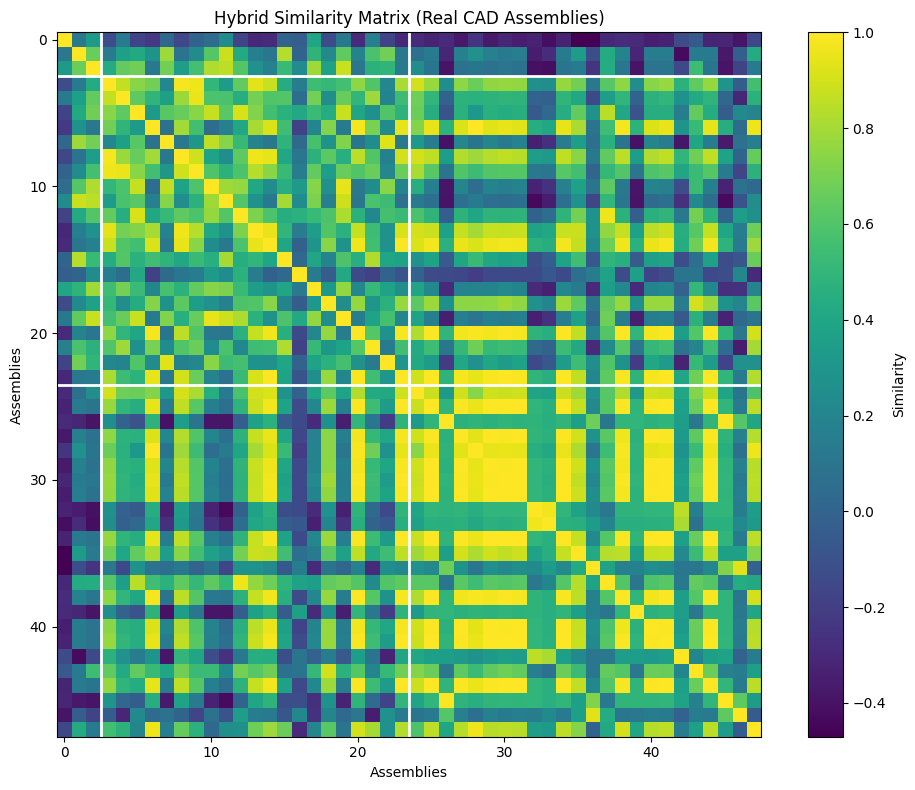

In [11]:

# ============================================================
# CELL 11 — HYBRID HEATMAP
# ============================================================

sorted_indices = np.argsort(labels)

sorted_similarity = hybrid_similarity[
    sorted_indices
][:, sorted_indices]

sorted_labels = labels[sorted_indices]

boundaries = []

for i in range(1, len(sorted_labels)):

    if sorted_labels[i] != sorted_labels[i - 1]:
        boundaries.append(i)

plt.figure(figsize=(10,8))

plt.imshow(sorted_similarity)

for b in boundaries:

    plt.axhline(
        b - 0.5,
        color='white',
        linewidth=2
    )

    plt.axvline(
        b - 0.5,
        color='white',
        linewidth=2
    )

plt.colorbar(label='Similarity')

plt.title(
    "Hybrid Similarity Matrix "
    "(Real CAD Assemblies)"
)

plt.xlabel("Assemblies")
plt.ylabel("Assemblies")

plt.tight_layout()

plt.savefig(
    "figures/hybrid_heatmap.pdf"
)

plt.show()


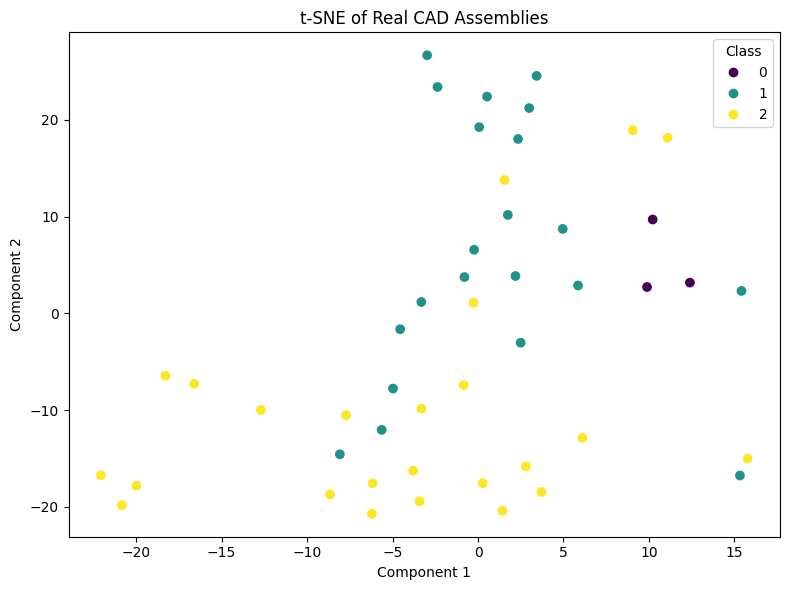

In [12]:

# ============================================================
# CELL 12 — t-SNE VISUALIZATION
# ============================================================

X = np.concatenate([

    tech_scaled,

    semantic_features.values,

    struct_scaled

], axis=1)

embedded = TSNE(

    n_components=2,

    random_state=42,

    perplexity=10

).fit_transform(X)

plt.figure(figsize=(8,6))

scatter = plt.scatter(

    embedded[:,0],

    embedded[:,1],

    c=labels

)

plt.title(
    "t-SNE of Real CAD Assemblies"
)

plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend(
    *scatter.legend_elements(),
    title="Class"
)

plt.tight_layout()

plt.savefig(
    "figures/tsne_embedding.pdf"
)

plt.show()


/var/folders/5g/xvbyr6sj6h9bmtvf5km0m3n80000gn/T/ipykernel_1332/3047709691.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


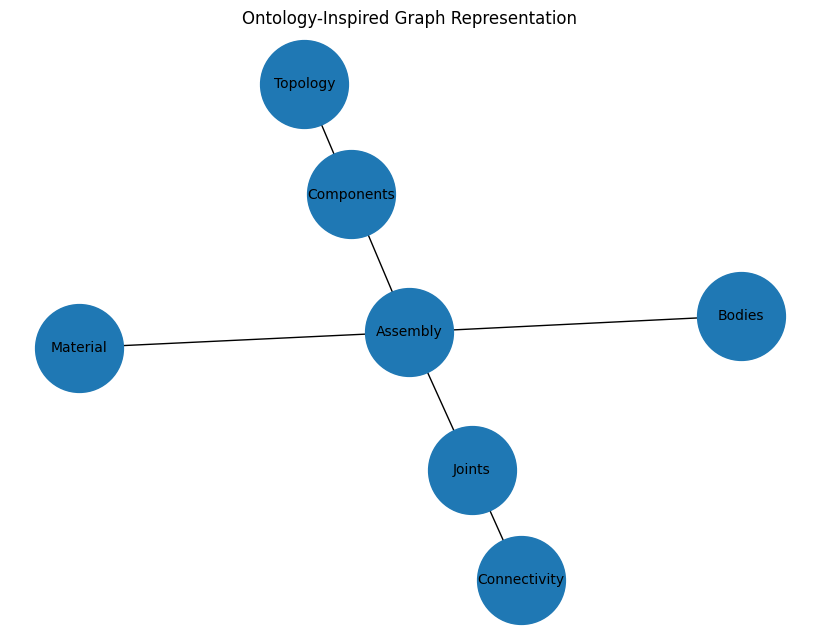

In [13]:

# ============================================================
# CELL 13 — ONTOLOGY GRAPH
# ============================================================

G = nx.Graph()

G.add_edges_from([

    ("Assembly", "Components"),
    ("Assembly", "Material"),
    ("Assembly", "Joints"),
    ("Assembly", "Bodies"),
    ("Components", "Topology"),
    ("Joints", "Connectivity")

])

plt.figure(figsize=(8,6))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=4000,
    font_size=10
)

plt.title(
    "Ontology-Inspired Graph Representation"
)

plt.tight_layout()

plt.savefig(
    "figures/ontology_graph.pdf"
)

plt.show()


/var/folders/5g/xvbyr6sj6h9bmtvf5km0m3n80000gn/T/ipykernel_1332/4070042991.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


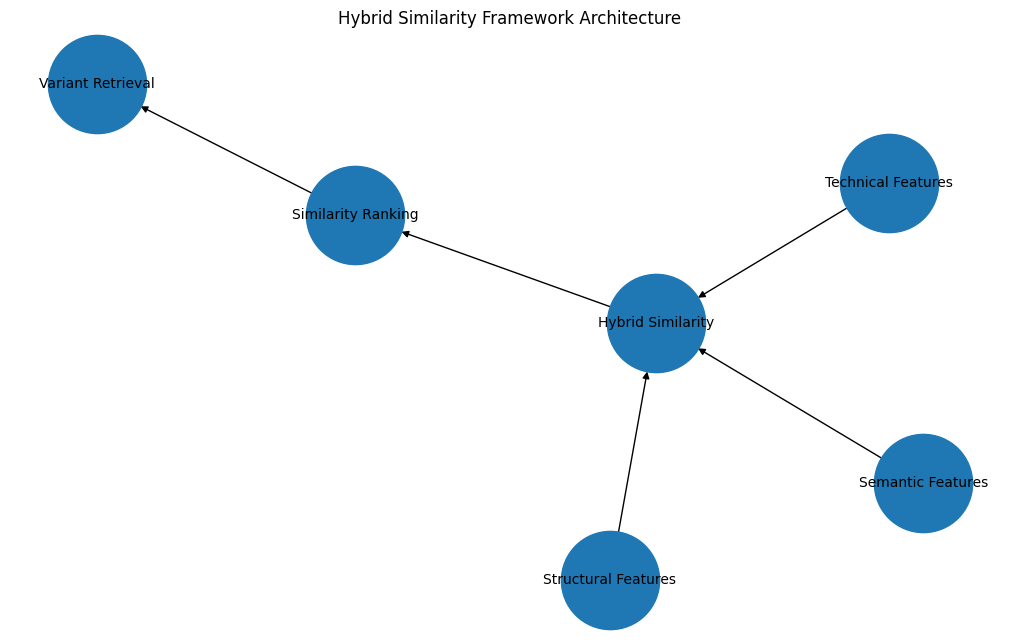

In [14]:

# ============================================================
# CELL 14 — HYBRID ARCHITECTURE
# ============================================================

G = nx.DiGraph()

G.add_edges_from([

    ("Technical Features", "Hybrid Similarity"),

    ("Semantic Features", "Hybrid Similarity"),

    ("Structural Features", "Hybrid Similarity"),

    ("Hybrid Similarity", "Similarity Ranking"),

    ("Similarity Ranking", "Variant Retrieval")

])

plt.figure(figsize=(10,6))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    font_size=10,
    arrows=True
)

plt.title(
    "Hybrid Similarity Framework Architecture"
)

plt.tight_layout()

plt.savefig(
    "figures/hybrid_framework_architecture.pdf"
)

plt.show()


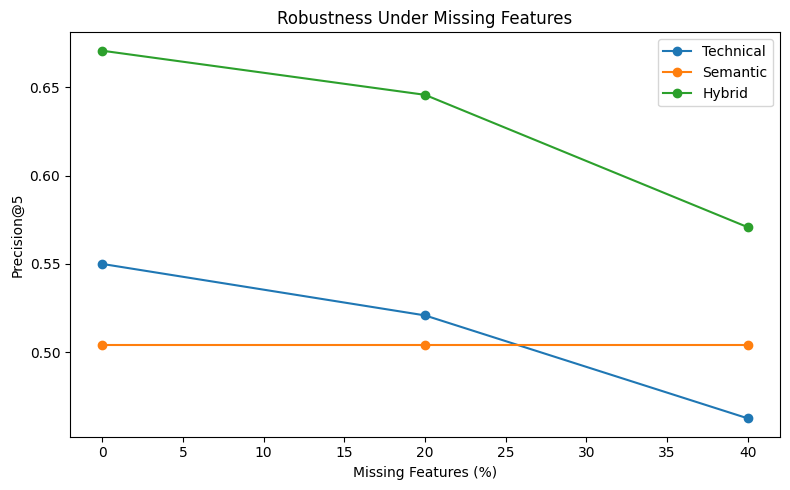

In [15]:

# ============================================================
# CELL 15 — ROBUSTNESS ANALYSIS
# ============================================================

def simulate_missing_features(X, missing_percent):

    X_copy = X.copy()

    total = X_copy.size

    missing = int(total * missing_percent)

    idx = np.random.choice(
        total,
        missing,
        replace=False
    )

    flat = X_copy.flatten()

    flat[idx] = 0

    return flat.reshape(X_copy.shape)

missing_levels = [0, 0.2, 0.4]

technical_scores = []
semantic_scores = []
hybrid_scores = []

for m in missing_levels:

    tech_missing = simulate_missing_features(
        tech_scaled,
        m
    )

    struct_missing = simulate_missing_features(
        struct_scaled,
        m
    )

    tech_sim = cosine_similarity(
        tech_missing
    )

    struct_sim = cosine_similarity(
        struct_missing
    )

    hybrid_missing = (
        alpha * tech_sim +
        beta * semantic_similarity +
        gamma * struct_sim
    )

    technical_scores.append(
        precision_at_k(
            tech_sim,
            labels
        )
    )

    semantic_scores.append(
        precision_at_k(
            semantic_similarity,
            labels
        )
    )

    hybrid_scores.append(
        precision_at_k(
            hybrid_missing,
            labels
        )
    )

robustness_table = pd.DataFrame({

    "Missing Features (%)": [
        int(x*100) for x in missing_levels
    ],

    "Technical": technical_scores,

    "Semantic": semantic_scores,

    "Hybrid": hybrid_scores
})

robustness_table.to_csv(
    "tables/robustness_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.plot(
    [x*100 for x in missing_levels],
    technical_scores,
    marker='o',
    label='Technical'
)

plt.plot(
    [x*100 for x in missing_levels],
    semantic_scores,
    marker='o',
    label='Semantic'
)

plt.plot(
    [x*100 for x in missing_levels],
    hybrid_scores,
    marker='o',
    label='Hybrid'
)

plt.xlabel("Missing Features (%)")
plt.ylabel("Precision@5")

plt.title(
    "Robustness Under Missing Features"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/robustness_analysis.pdf"
)

plt.show()


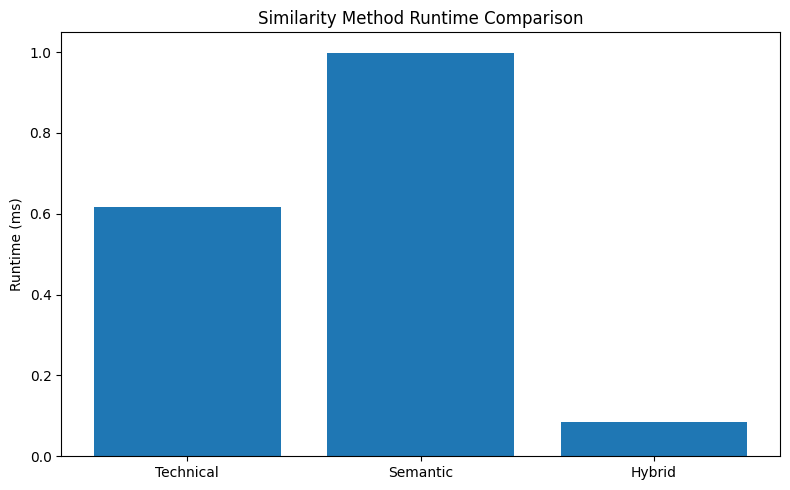

In [16]:

# ============================================================
# CELL 16 — RUNTIME BENCHMARKING
# ============================================================

runtime_results = {}

start = time.time()

cosine_similarity(
    tech_scaled
)

runtime_results["Technical"] = (
    time.time() - start
) * 1000

start = time.time()

cosine_similarity(
    semantic_features
)

runtime_results["Semantic"] = (
    time.time() - start
) * 1000

start = time.time()

_ = (
    alpha * technical_similarity +
    beta * semantic_similarity +
    gamma * structural_similarity
)

runtime_results["Hybrid"] = (
    time.time() - start
) * 1000

runtime_table = pd.DataFrame({

    "Method": list(runtime_results.keys()),

    "Runtime (ms)": list(runtime_results.values())
})

runtime_table.to_csv(
    "tables/runtime_results.csv",
    index=False
)

plt.figure(figsize=(8,5))

plt.bar(
    runtime_table["Method"],
    runtime_table["Runtime (ms)"]
)

plt.ylabel("Runtime (ms)")

plt.title(
    "Similarity Method Runtime Comparison"
)

plt.tight_layout()

plt.savefig(
    "figures/runtime_comparison.pdf"
)

plt.show()


In [17]:

# ============================================================
# CELL 17 — k-NN CLASSIFICATION
# ============================================================

X_ml = np.concatenate([

    tech_scaled,

    semantic_features.values,

    struct_scaled

], axis=1)

X_train, X_test, y_train, y_test = train_test_split(

    X_ml,

    labels,

    test_size=0.3,

    random_state=42
)

knn = KNeighborsClassifier(
    n_neighbors=3
)

knn.fit(
    X_train,
    y_train
)

preds = knn.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    preds
)

report = classification_report(

    y_test,

    preds,

    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "tables/knn_classification_report.csv"
)

print("k-NN Accuracy:", accuracy)

print(report_df)


k-NN Accuracy: 0.7333333333333333
              precision    recall  f1-score    support
0              0.000000  0.000000  0.000000   2.000000
1              0.600000  0.600000  0.600000   5.000000
2              0.800000  1.000000  0.888889   8.000000
accuracy       0.733333  0.733333  0.733333   0.733333
macro avg      0.466667  0.533333  0.496296  15.000000
weighted avg   0.626667  0.733333  0.674074  15.000000


/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [18]:

# ============================================================
# CELL 18 — RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_preds = rf.predict(
    X_test
)

rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)

rf_report = classification_report(

    y_test,

    rf_preds,

    output_dict=True
)

rf_report_df = pd.DataFrame(
    rf_report
).transpose()

rf_report_df.to_csv(
    "tables/random_forest_classification_report.csv"
)

print("Random Forest Accuracy:", rf_accuracy)

print(rf_report_df)


Random Forest Accuracy: 0.6666666666666666
              precision    recall  f1-score    support
0              0.000000  0.000000  0.000000   2.000000
1              0.500000  0.600000  0.545455   5.000000
2              0.777778  0.875000  0.823529   8.000000
accuracy       0.666667  0.666667  0.666667   0.666667
macro avg      0.425926  0.491667  0.456328  15.000000
weighted avg   0.581481  0.666667  0.621034  15.000000


/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ulukbekrahmanov/Desktop/SimilarityThesis/thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [19]:

# ============================================================
# CELL 19 — ROC-AUC EVALUATION
# ============================================================

y_test_bin = label_binarize(
    y_test,
    classes=np.unique(labels)
)

# k-NN probabilities

knn_probs = knn.predict_proba(
    X_test
)

knn_auc = roc_auc_score(

    y_test_bin,

    knn_probs,

    multi_class='ovr'
)

# Random Forest probabilities

rf_probs = rf.predict_proba(
    X_test
)

rf_auc = roc_auc_score(

    y_test_bin,

    rf_probs,

    multi_class='ovr'
)

roc_results = pd.DataFrame({

    "Model": [

        "k-NN",

        "Random Forest"

    ],

    "ROC-AUC": [

        knn_auc,

        rf_auc
    ]
})

roc_results.to_csv(
    "tables/roc_auc_results.csv",
    index=False
)

print(roc_results)


           Model   ROC-AUC
0           k-NN  0.834762
1  Random Forest  0.890595


In [20]:

# ============================================================
# CELL 20 — DATASET SUMMARY
# ============================================================

summary_table = pd.DataFrame({

    "Statistic": [

        "Assemblies",

        "Technical Features",

        "Semantic Features",

        "Structural Features"
    ],

    "Value": [

        len(df),

        len(technical_features.columns),

        len(semantic_features.columns),

        len(structural_features.columns)
    ]
})

summary_table.to_csv(
    "tables/dataset_summary.csv",
    index=False
)

print(summary_table)


             Statistic  Value
0           Assemblies     48
1   Technical Features      4
2    Semantic Features      5
3  Structural Features      3
